In [1]:
options(width = 140)
script_candidates <- c("statistics_analysis_openmls_v9.R", file.path("statistics", "statistics_analysis_openmls_v9.R"))
script_path <- script_candidates[file.exists(script_candidates)][1]
stopifnot(!is.na(script_path))
source(script_path)
result <- openmls_v9_run(save_outputs = TRUE)
result$quick_table |>
  dplyr::select(-plot_label) |>
  print(n = Inf, width = Inf)
#Kalibrierung zwischen mehreren Architekturen in Research

constraint    increment  runs  status                           failure_or_slowdown                     worst_operation                         worst_member_count  data_quality
------------  ---------  ----  -------------------------------  --------------------------------------  --------------------------------------  ------------------  --------------------------------------
RAM app heap  32k        6     fails / attrited                 6/6 workers failed at key_package_cre~  key_package_create                      1                   worker_failures.csv + events.csv
RAM app heap  64k        6     fails / attrited                 6/6 workers failed at key_package_cre~  key_package_create                      1                   worker_failures.csv + events.csv
RAM app heap  128k       6     fails / attrited                 6/6 workers failed at key_package_cre~  key_package_create                      1                   worker_failures.csv + events.csv
RAM app heap  512k       6   

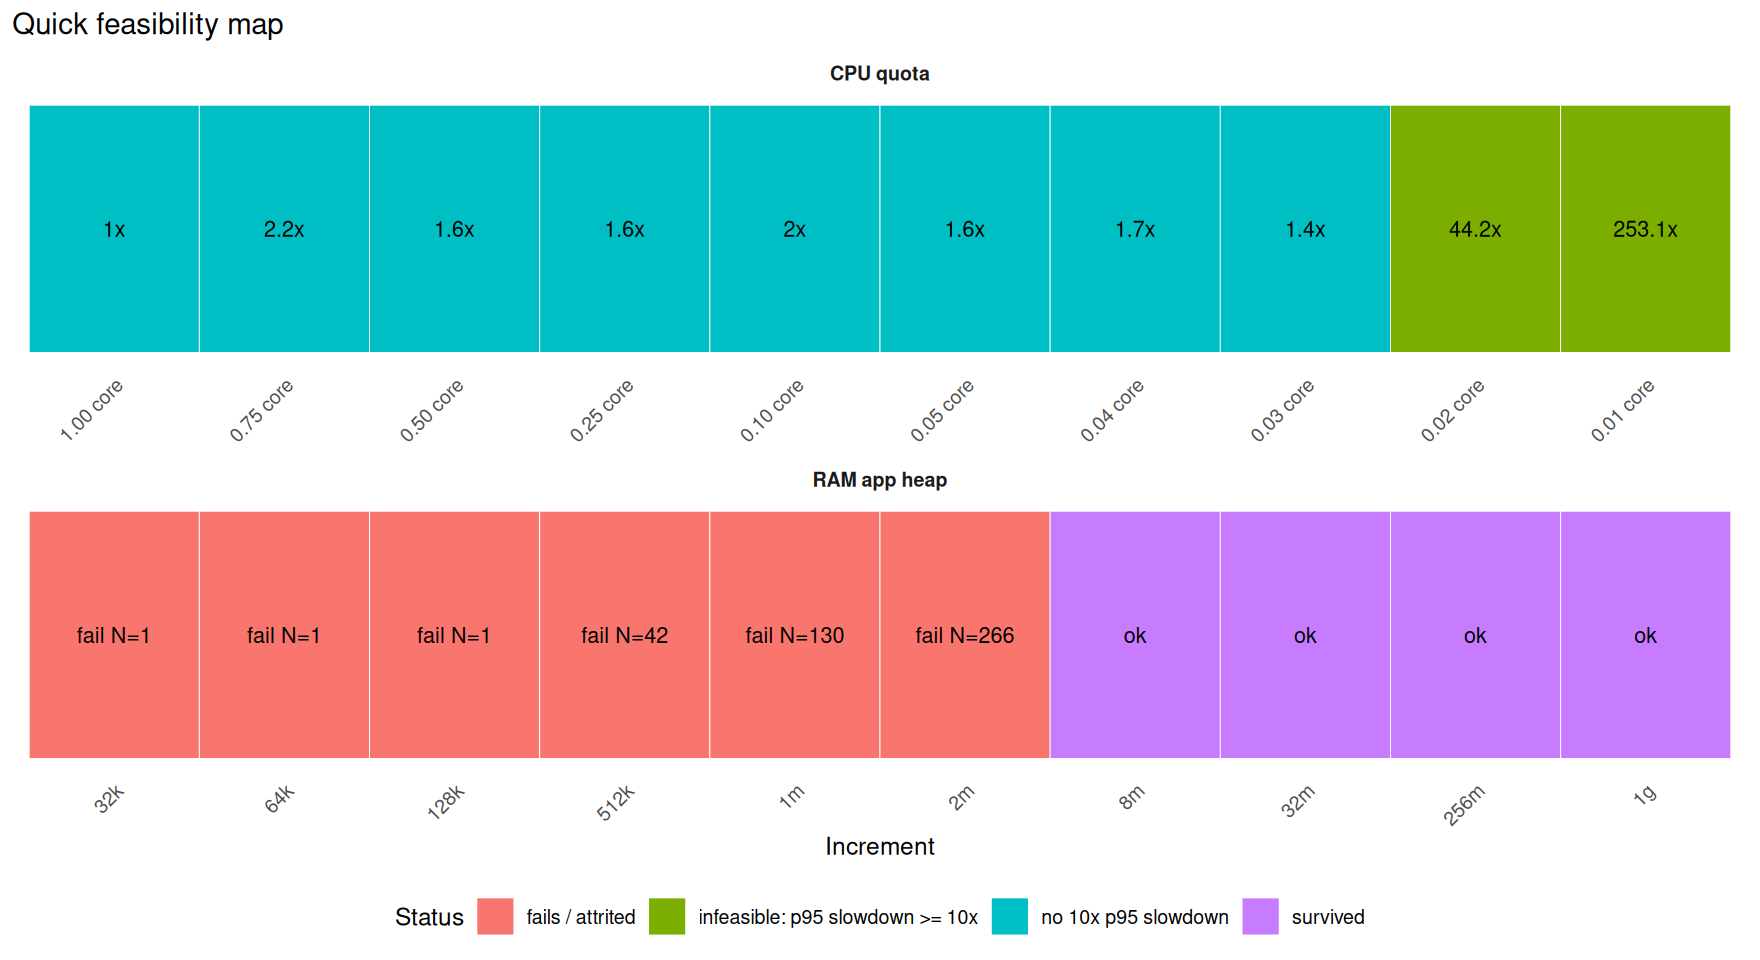

In [2]:
result$plots$quick_overview

In [3]:
result$run_inventory |>
  dplyr::select(run_id, run_kind, has_events, events_rows, has_resource_summary, has_worker_failures, outcome_class, terminal_finished) |>
  print(n = Inf, width = Inf)

run_id                                  run_kind                   has_events  events_rows  has_resource_summary  has_worker_failures  outcome_class             terminal_finished
--------------------------------------  -------------------------  ----------  -----------  --------------------  -------------------  ------------------------  -----------------
cal01_cpu-quota-sweep_i1_20260626_030~  01 constrained CPU         FALSE       0            TRUE                  FALSE                unknown                   FALSE
cal01_cpu-quota-sweep_i1_20260626_032~  01 constrained CPU         FALSE       0            TRUE                  FALSE                unknown                   FALSE
cal01_cpu-quota-sweep_i1_20260626_100~  01 constrained CPU         TRUE        156659       TRUE                  TRUE                 success                   TRUE
cal01_cpu-quota-sweep_i2_20260626_100~  01 constrained CPU         TRUE        156727       TRUE                  TRUE                 success

resource_profile_id  app_heap_budget  heap_bytes  profile_index  runs  profiled_workers  failures  survived  first_failure_operation      min_failure_member_count  median_failure_peak_kib  failure_action                          status
-------------------  ---------------  ----------  -------------  ----  ----------------  --------  --------  ---------------------------  ------------------------  -----------------------  --------------------------------------  ----------------
ram_app_heap_32k     32k              32768       0              6     6                 6         0         key_package_create           1                         88.5                     drop_idle_joiner                        fails / attrited
ram_app_heap_64k     64k              65536       1              6     6                 6         0         key_package_create           1                         88                       drop_idle_joiner                        fails / attrited
ram_app_heap_128k    128k 

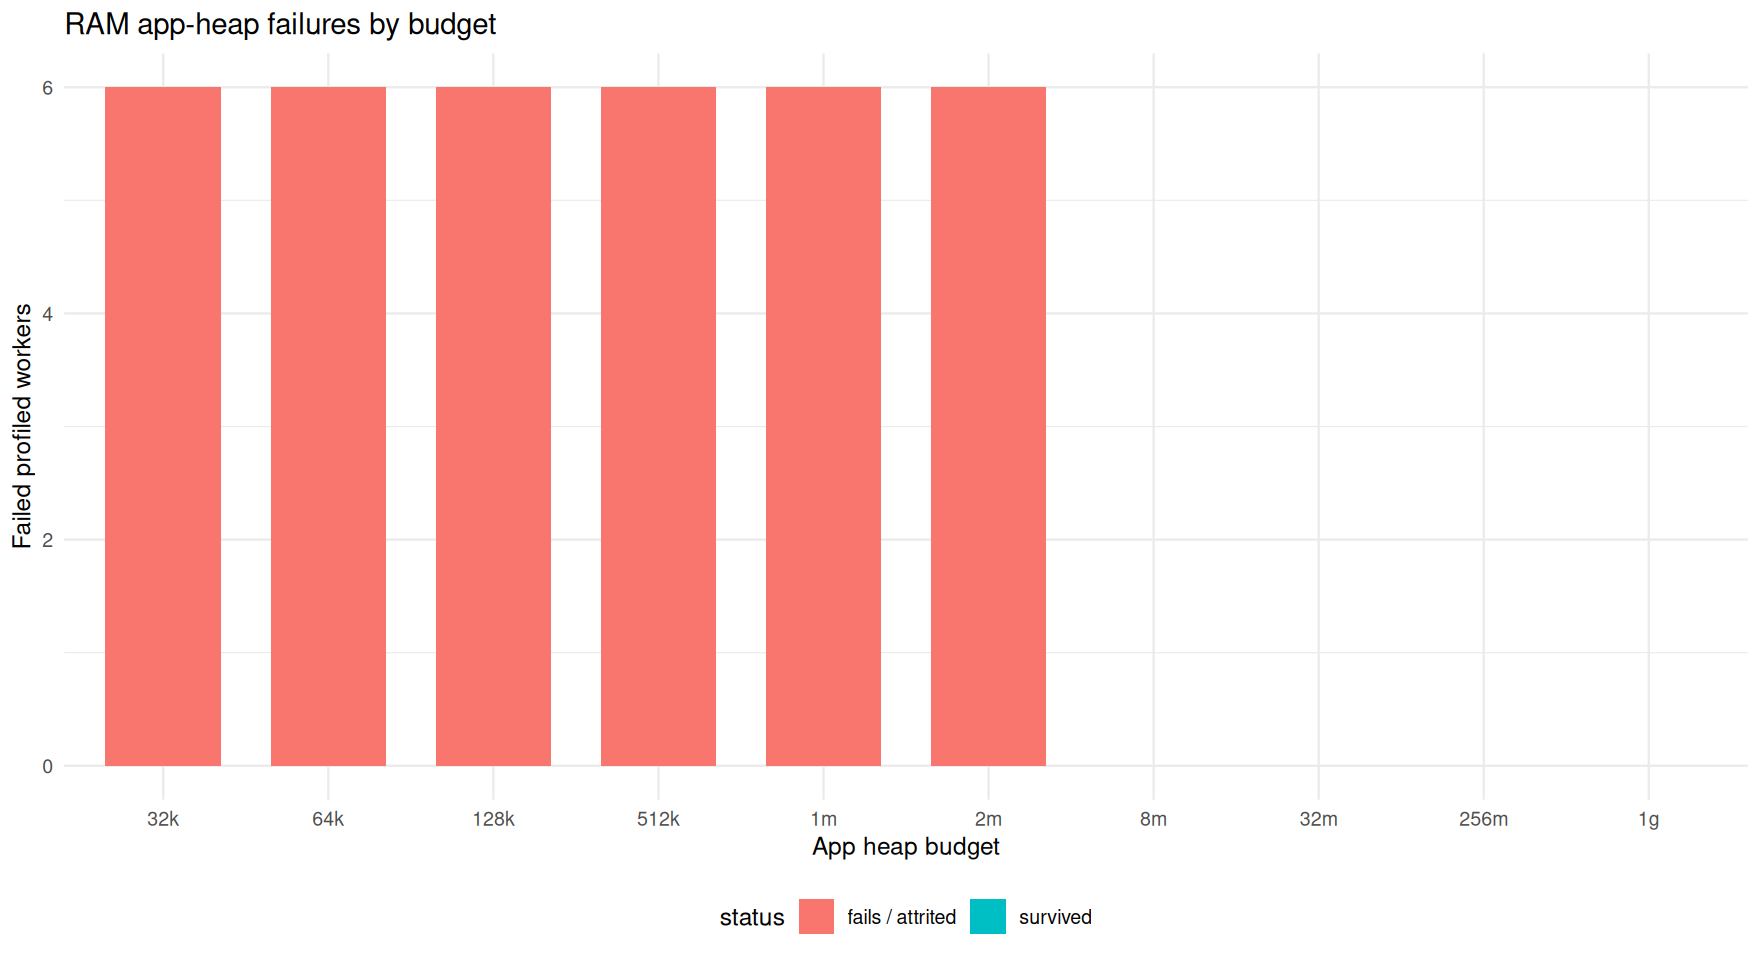

In [4]:
print(result$ram_table, n = Inf, width = Inf)
result$plots$ram_failures

resource_profile_id  cpu_fraction  cpu_limit  profile_index  runs  profiled_workers  event_csv_available  event_rows  matched_operation_strata  median_event_p95_slowdown  p95_event_slowdown  max_event_slowdown  worst_phase        worst_operation                         max_group_size_seen  median_cpu_throttled_period_fraction  max_cpu_throttled_period_fraction  median_nr_throttled  median_cpu_throttled_time_rate  max_cpu_throttled_time_rate  status
-------------------  ------------  ---------  -------------  ----  ----------------  -------------------  ----------  ------------------------  -------------------------  ------------------  ------------------  -----------------  --------------------------------------  -------------------  ------------------------------------  ---------------------------------  -------------------  ------------------------------  ---------------------------  -------------------------------
cpu_quota_1p0        1             1          0              3     3 

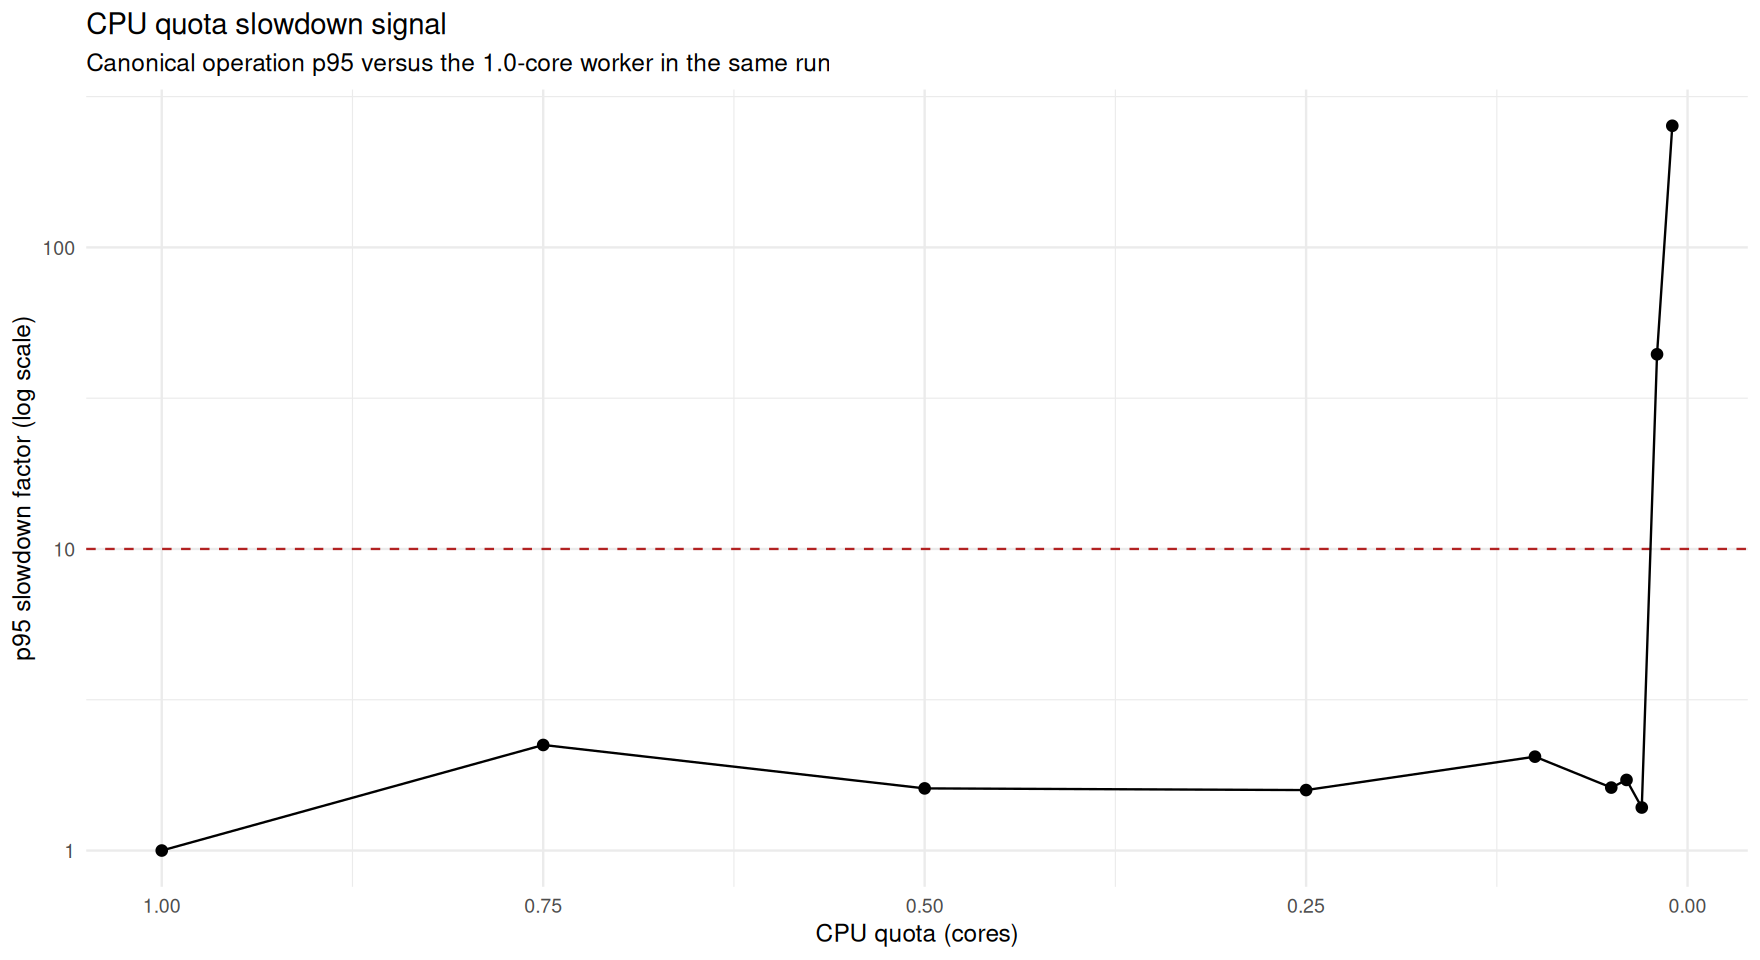

In [5]:
print(result$cpu_table, n = Inf, width = Inf)
result$plots$cpu_slowdown

run_kind                   platform    operation_family             n       p50_wall_ms  p95_wall_ms  median_alloc_kib  max_target_size
-------------------------  ----------  ---------------------------  ------  -----------  -----------  ----------------  ---------------
01 constrained CPU         Containers  add_commit_create            12639   0.169        18.3         90.6              1024
01 constrained CPU         Containers  application_message_create   37148   0.0315       0.992        2.15              1024
01 constrained CPU         Containers  application_message_receive  166082  0.0112       0.945        0.85              1024
01 constrained CPU         Containers  commit_receive               229423  0.172        11.6         32                1024
01 constrained CPU         Containers  key_package_create           27      0.21         0.264        11.1              NA
01 constrained CPU         Containers  remove_commit_create         364     0.2          927          28.

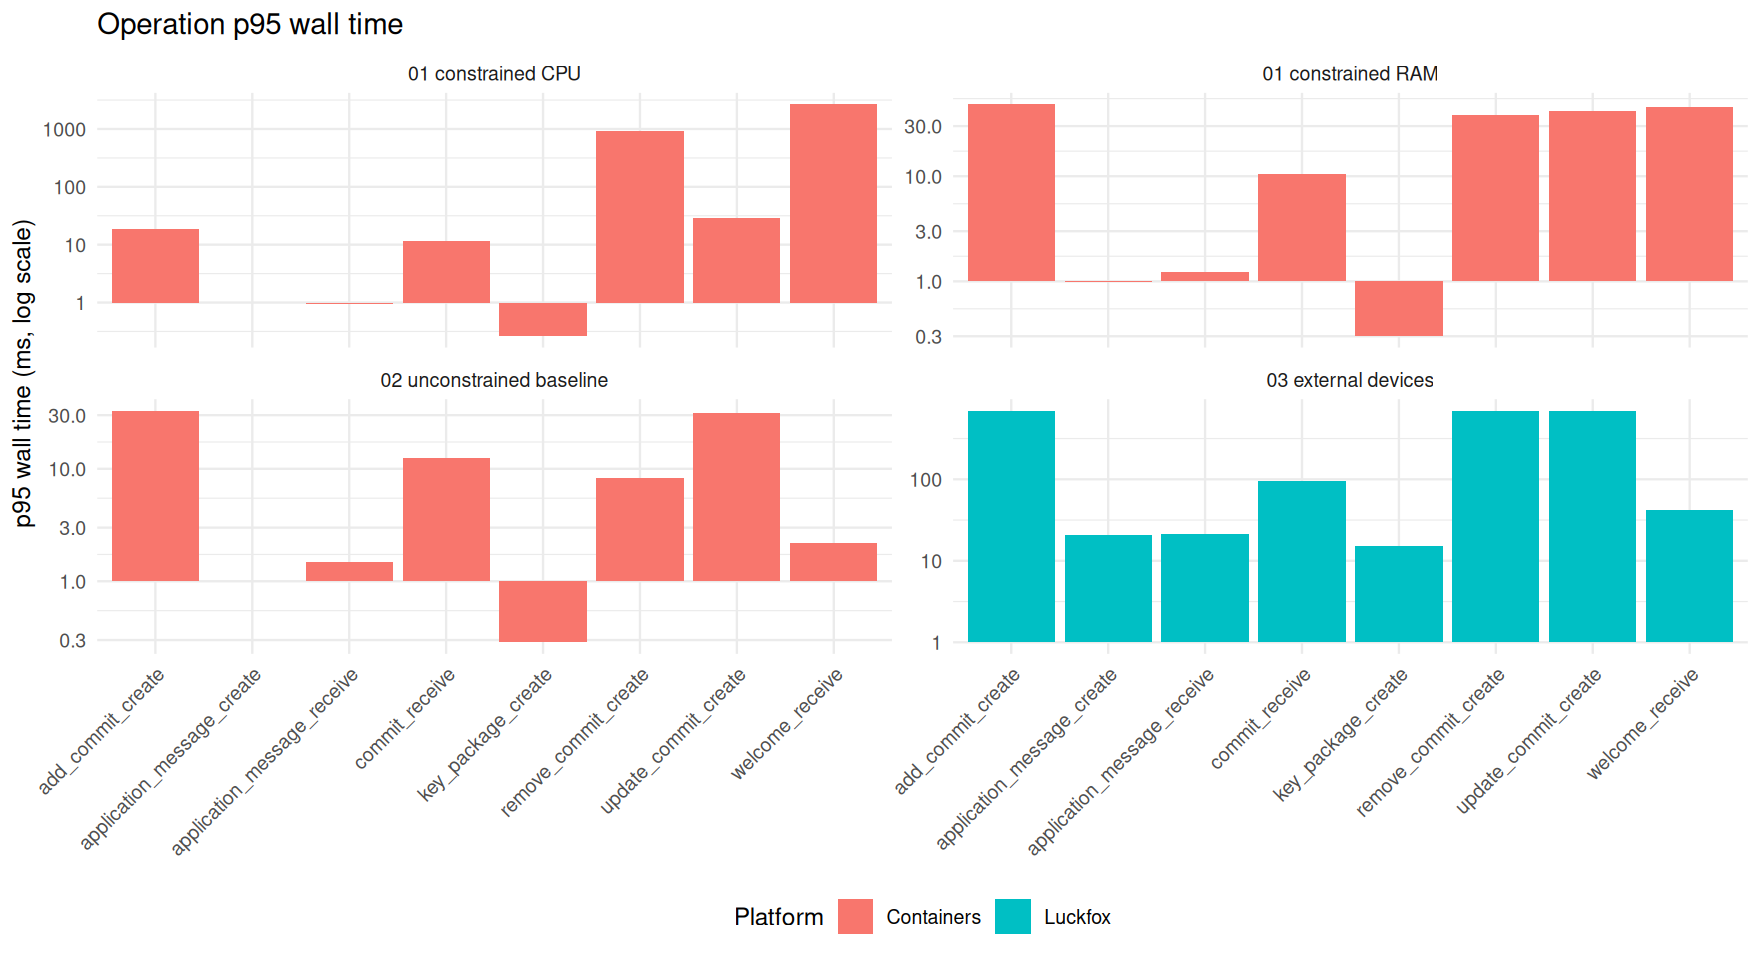

In [6]:
result$operation_summary |>
  dplyr::arrange(run_kind, platform, dplyr::desc(p95_wall_ms)) |>
  print(n = 80, width = Inf)
result$plots$operation_p95

run_kind            platform    operation_family             op                                      n      p95_wall_ms  p95_alloc_kib
------------------  ----------  ---------------------------  --------------------------------------  -----  -----------  -------------
01 constrained CPU  Containers  add_commit_create            commit_create_protocol_add              576    26.7         9.05e+03
01 constrained CPU  Containers  add_commit_create            update_path_compute_protocol_core       576    14.3         949
01 constrained CPU  Containers  add_commit_create            commit_add.path_hpke_encrypt            576    11.3         203
01 constrained CPU  Containers  add_commit_create            welcome_create_protocol                 576    8.64         5.63e+03
01 constrained CPU  Containers  add_commit_create            commit_add.welcome_group_secrets_encr~  576    4.37         3.91e+03
01 constrained CPU  Containers  add_commit_create            commit_add.group_info.sign   

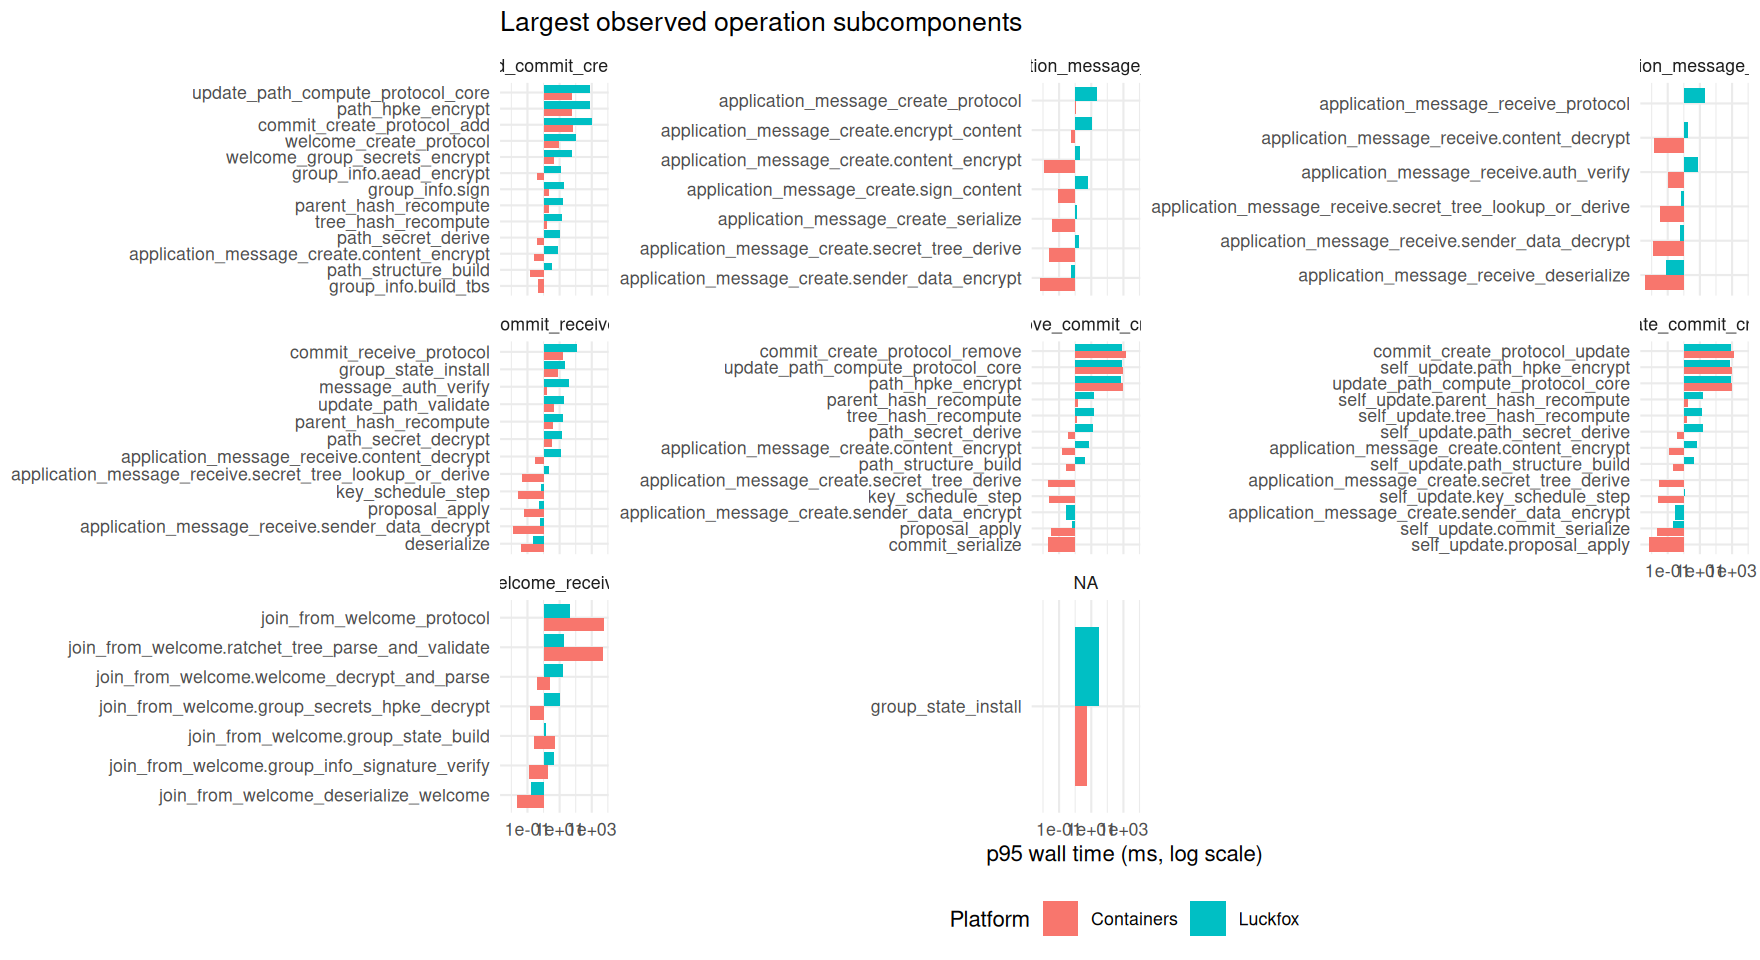

In [7]:
result$component_summary |>
  dplyr::arrange(run_kind, operation_family, dplyr::desc(p95_wall_ms)) |>
  print(n = 120, width = Inf)
result$plots$components

platform  operation_family             n     p50_wall_ms  p95_wall_ms
--------  ---------------------------  ----  -----------  -----------
Luckfox   add_commit_create            4202  3.61         692
Luckfox   application_message_create   8160  2.16         20.9
Luckfox   application_message_receive  6720  0.644        21.5
Luckfox   commit_receive               7334  5.76         95.2
Luckfox   key_package_create           5     12           15.3
Luckfox   remove_commit_create         1162  6.13         693
Luckfox   update_commit_create         4760  4.17         683
Luckfox   welcome_receive              40    10.9         42.5
Luckfox   NA                           614   19           31.1


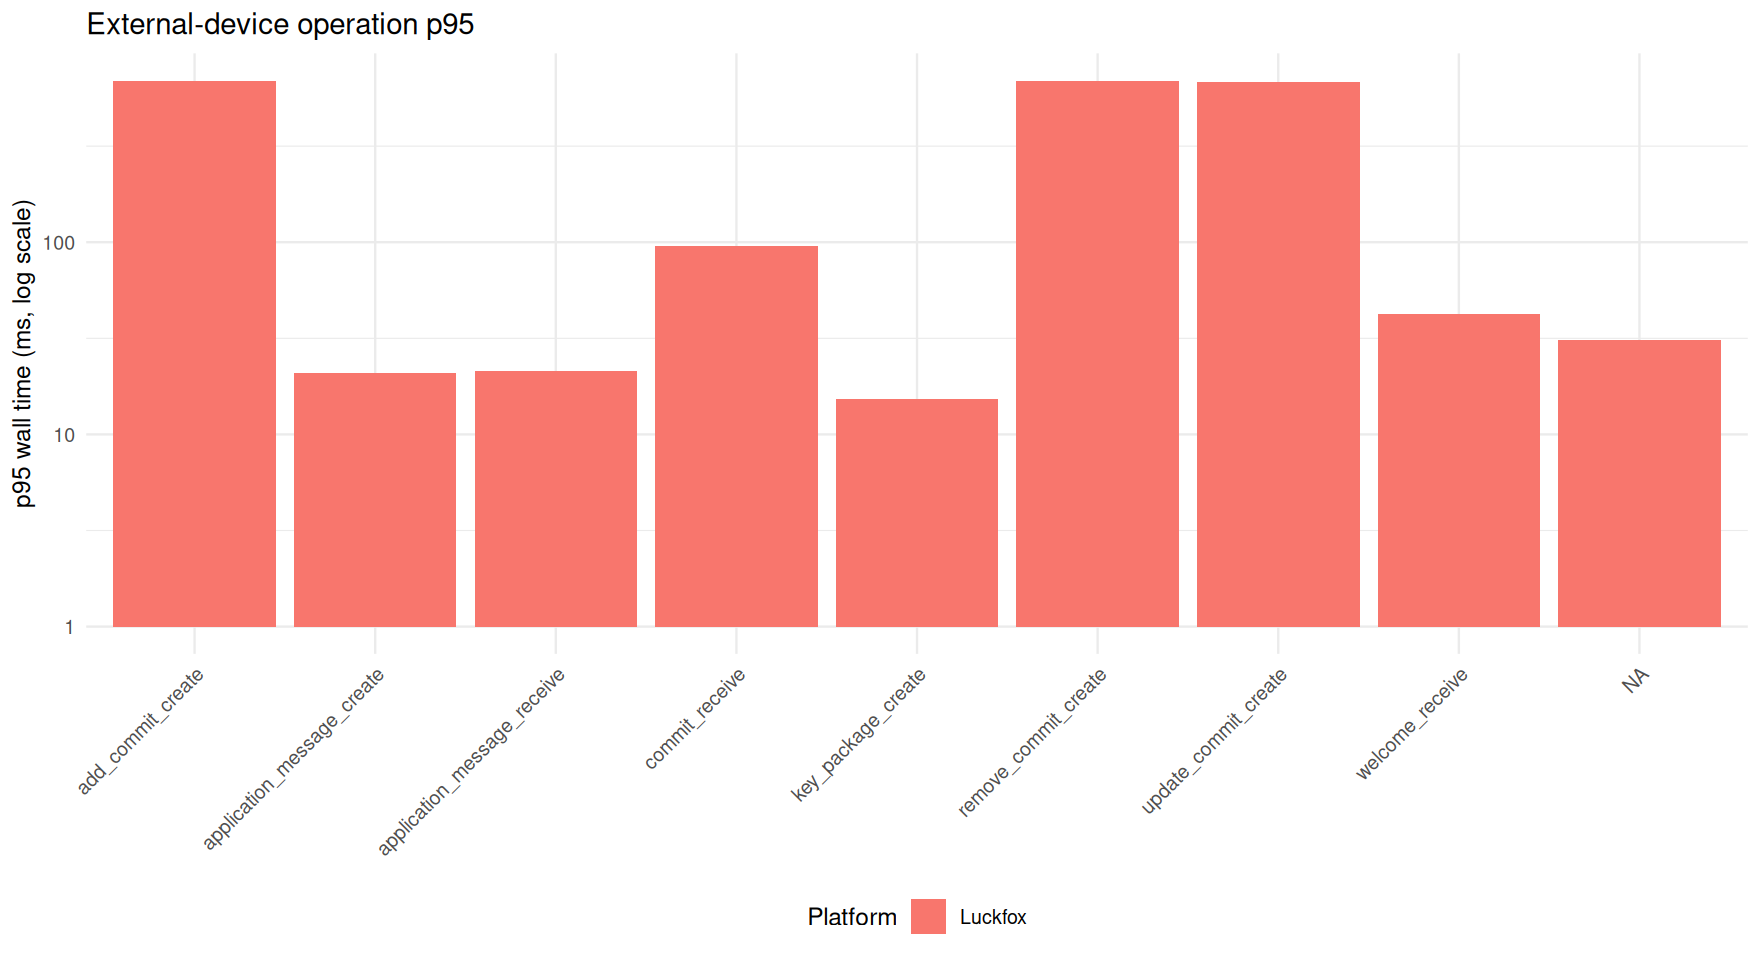

In [8]:
print(result$external_summary, n = Inf, width = Inf)
result$plots$external

In [9]:
list.files(result$output_dir, full.names = TRUE)

/home/diel/RustroverProjects/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/01_quick_overview.png
/home/diel/RustroverProjects/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/02_ram_failures.png
/home/diel/RustroverProjects/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/03_cpu_slowdown.png
/home/diel/RustroverProjects/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/04_operation_p95.png
/home/diel/RustroverProjects/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/05_components.png
/home/diel/RustroverProjects/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/06_external_devices.png
/home/diel/RustroverProjects/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/component_summary.csv
/home/diel/RustroverProjects/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/cpu_slowdown_table.csv
/home/diel/RustroverProjects/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/ex